# Exploring model results

Inspects the predictions of a trained `GNN_LSTM` on a test set. `framework/test.py` writes two parquet files per scenario:

- `df_node_<channel>.parquet`: one row per node per system, holding the true and predicted time series (`y_true`, `y_pred`) and the error metrics;
- `df_graph_<channel>.parquet`:  one row per system, the same error metrics as df_node but averaged over its nodes.

The metrics are MAE, APE, TRAC, RMSE, NRMSE and R² (defined in `framework/utils.py:node_metrics`).

The notebook will print the error metrics averaged over the population, then a figure showing how the error changes across the length of the beam. The reconstructed signal are plotted for all the nodes of an average performing system and compared with the ground truth in time domain. Lastly the distribution of error metrics over the population is plotted.

In [6]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["CMU Serif", "DejaVu Serif"],
    "mathtext.fontset": "cm",
})

COLOR_DATA  = "#1f77b4"
LABEL_GT    = "Ground truth"
LABEL_DATA  = "Data-driven"

label_font, ticks_font, title_font, legend_font = 15, 12, 14, 12

## Load results

In [ ]:
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

experiment_name = "example"
channel = "acc"
error_path = PROJECT_ROOT /experiment_name
df_node  = pd.read_parquet(error_path / f"df_node_{channel}.parquet")
df_graph = pd.read_parquet(error_path / f"df_graph_{channel}.parquet")

df_node.head()

,sys_id,n_nodes,node_pos,y_true,y_pred,mae,ape,trac,rmse,nrmse,r2
0,0,30,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.03445062, -0.014056735, 0.01766117, 0.02719...",0.000704,NaN,NaN,0.001535,NaN,NaN
1,0,30,2,"[1.2487932, -1.6784321, -1.2170463, -2.6416621...","[1.9948895, -0.98964536, -1.5632288, -2.758661...",0.120226,4.952310,0.997564,0.152123,0.007875,0.997530
2,0,30,3,"[5.0065503, -6.0162244, -4.813402, -10.346009,...","[7.3610377, -3.9956396, -6.0170097, -10.698625...",0.409579,4.472520,0.998003,0.519530,0.007119,0.997975
3,0,30,4,"[11.284549, -12.039393, -10.707728, -22.79648,...","[15.072402, -8.956129, -13.030964, -23.522097,...",0.778972,4.011743,0.998401,0.983764,0.006350,0.998385
4,0,30,5,"[20.078905, -18.79932, -18.805153, -39.657448,...","[24.577015, -14.9761915, -21.8308, -40.275875,...",1.140504,3.514745,0.998782,1.441019,0.005560,0.998759


## Mean metrics over the population

In [8]:
metric_cols = ["ape", "r2", "rmse", "trac"]
print(df_graph[metric_cols].mean().to_frame(name="mean"))

           mean
ape    8.146357
r2     0.981200
rmse  11.681334
trac   0.985787


## Error vs. node position

APE distribution (over all test systems) at each node, on a log scale. This shows where along the beam the reconstruction is hard. Node 1 corresponds with the clamped end of the bean, consequently there is no movement: APE is undefined (`NaN`) and it drops out of the plot.

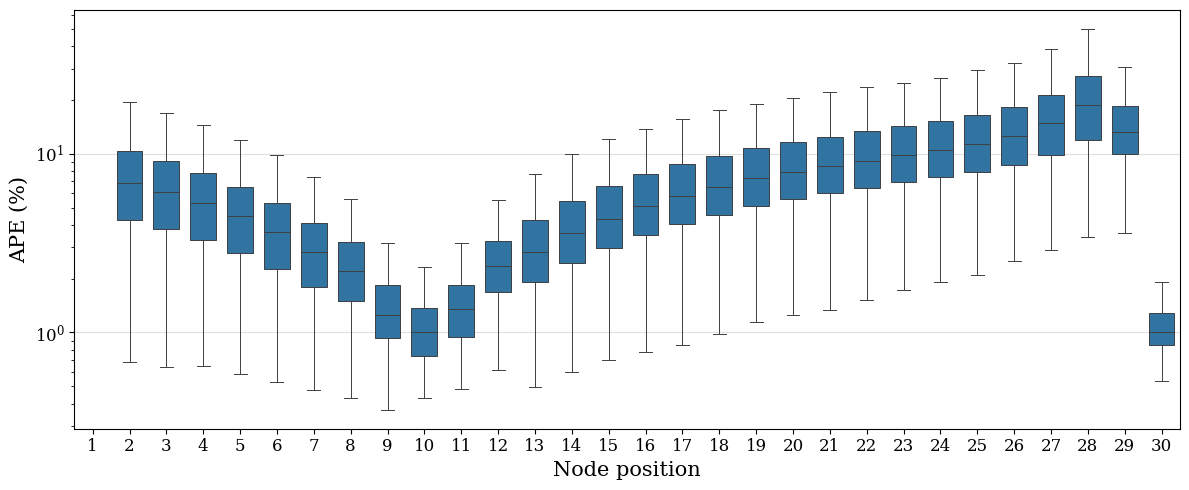

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.boxplot(
    data=df_node, x="node_pos", y="ape",
    color=COLOR_DATA, width=0.7, fliersize=0, linewidth=0.7, showfliers=False, ax=ax,
)

ax.set_yscale("log")
ax.set_xlabel("Node position", fontsize=label_font)
ax.set_ylabel("APE (%)", fontsize=label_font)
ax.tick_params(axis="both", labelsize=ticks_font)
ax.grid(which="major", axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

## Predicted vs. true time series

After picking a system that performs closest to the population average the reconstructed signals are plotted for every node and compared with the ground truth. The x-axis is zoomed to a 0.2 s window for better readability

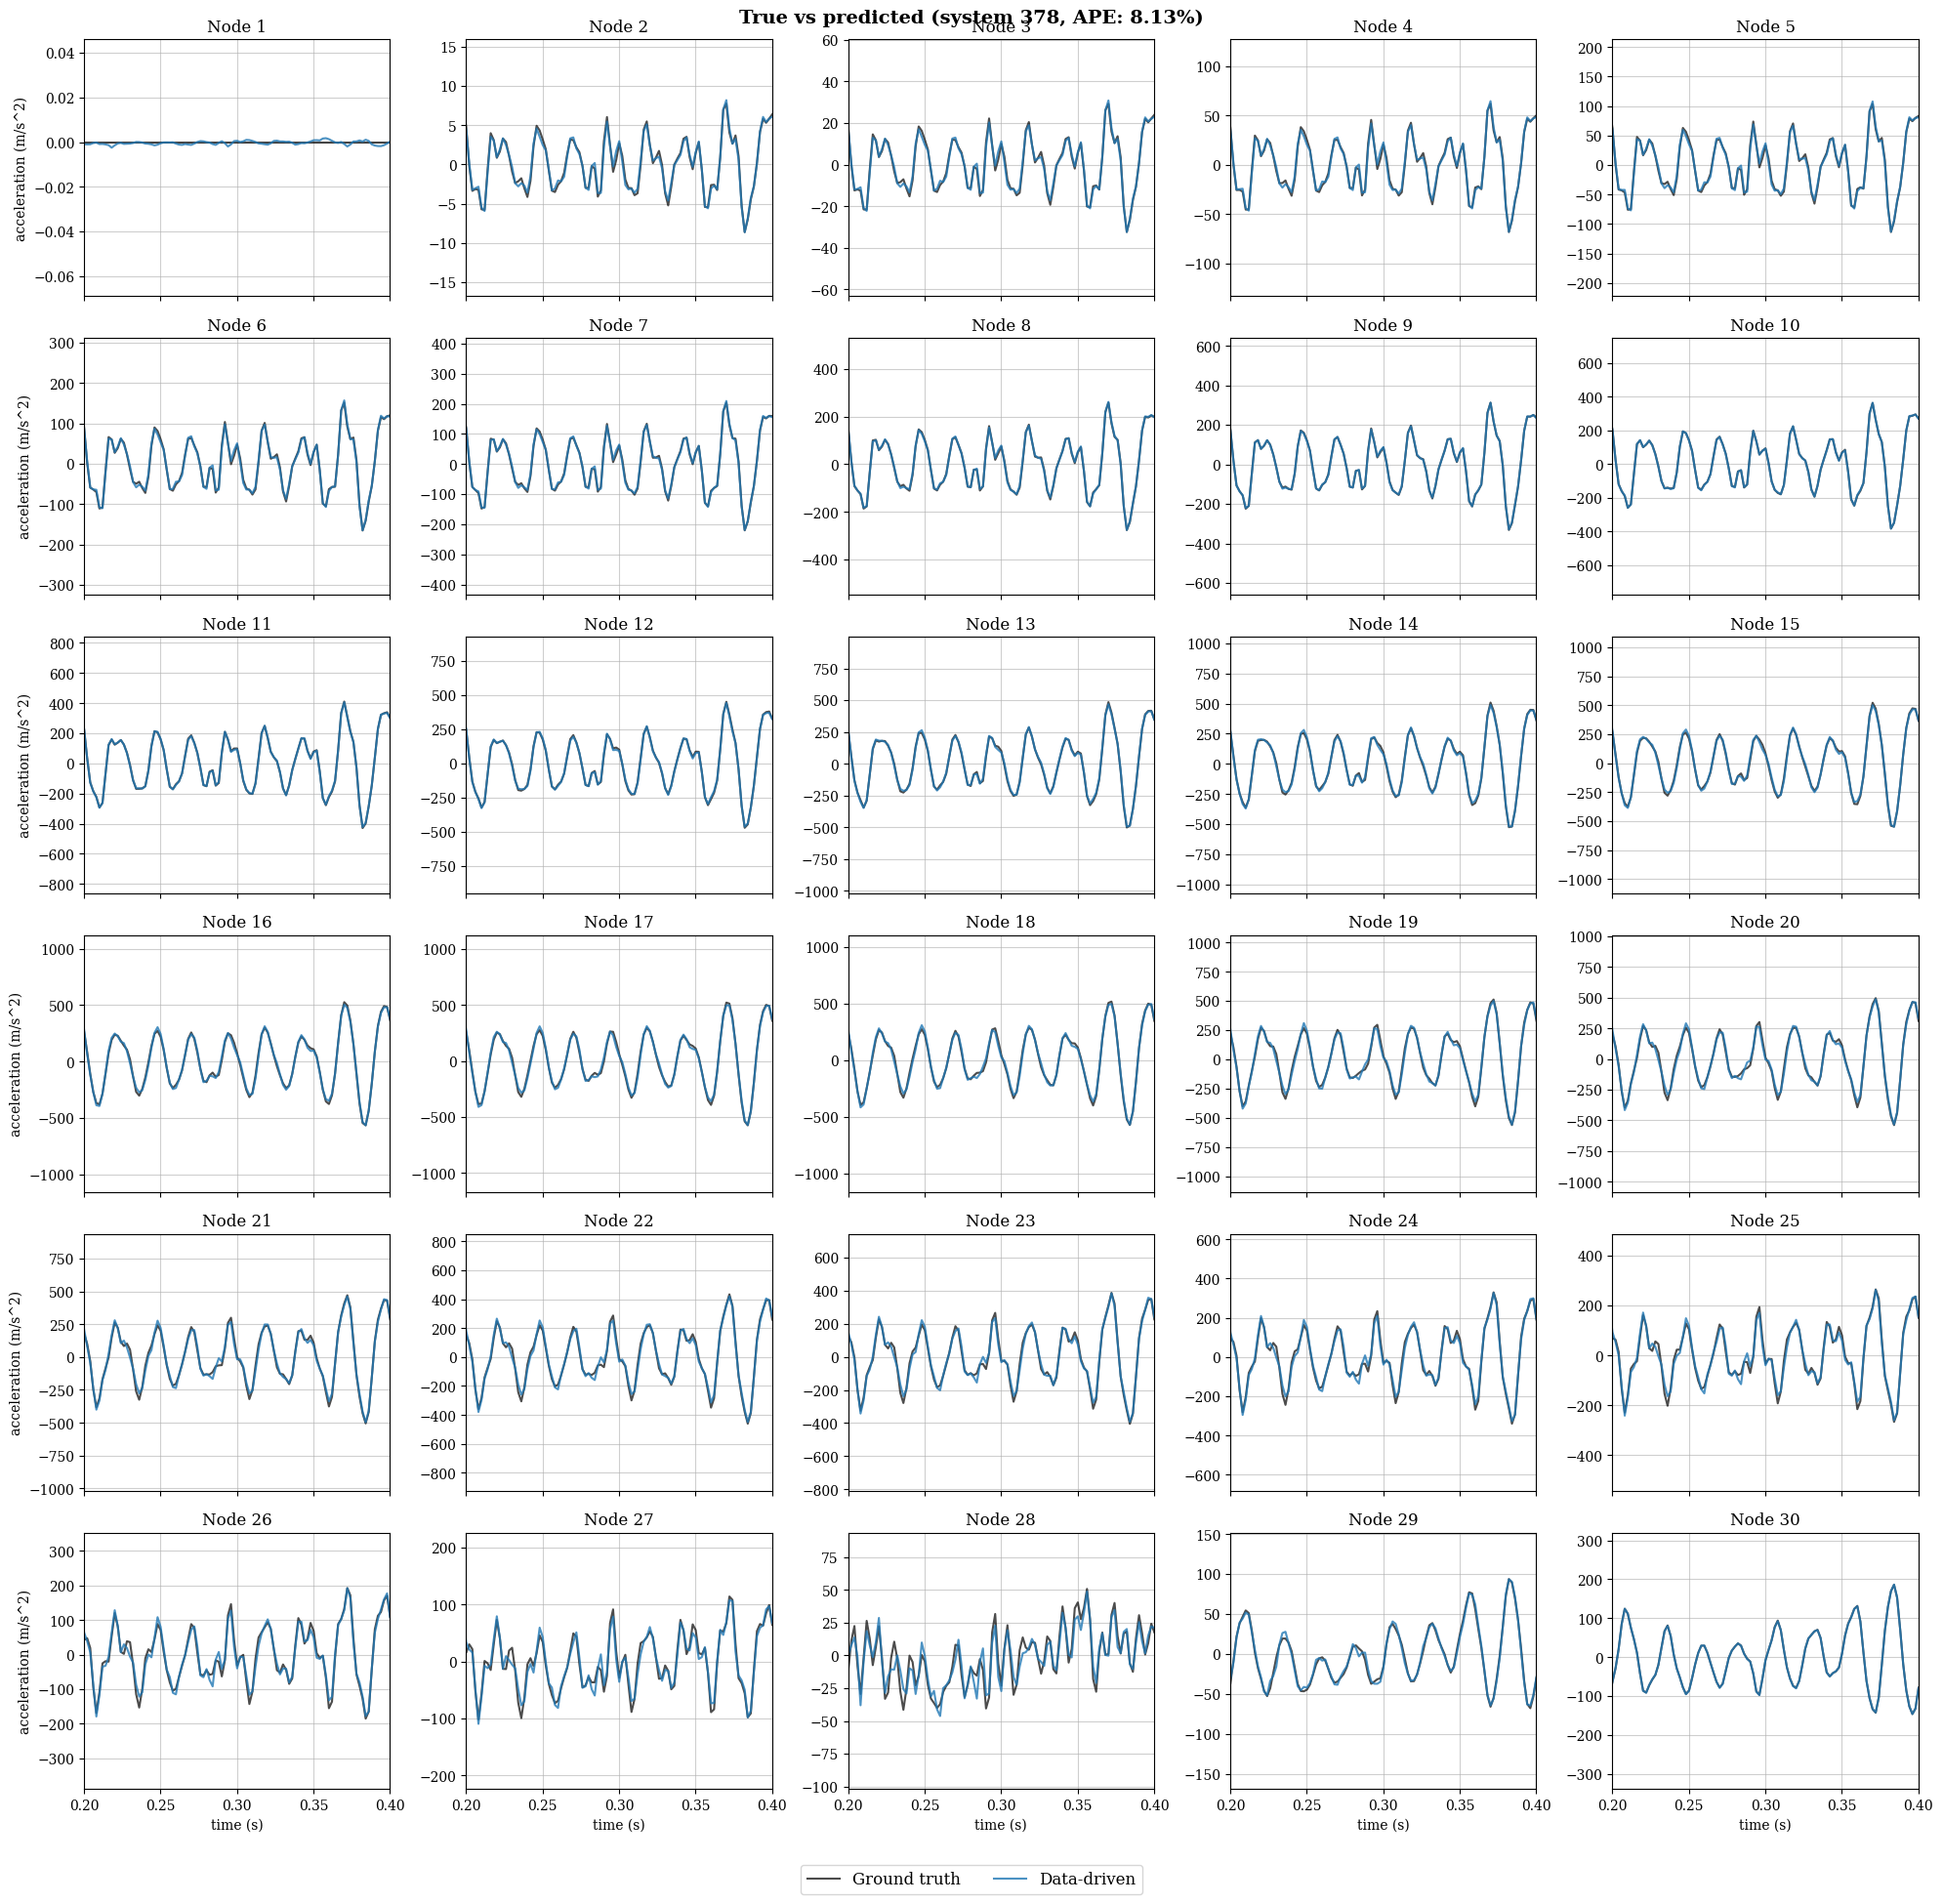

In [ ]:
mean_ape = df_graph["ape"].mean()
target_sys_id = df_graph.loc[(df_graph["ape"] - mean_ape).abs().idxmin(), "sys_id"]
ape_val = df_graph.loc[df_graph["sys_id"] == target_sys_id, "ape"].iloc[0]

sys_nodes = df_node[df_node["sys_id"] == target_sys_id]

n_nodes = len(sys_nodes)
cols = 5
rows = int(np.ceil(n_nodes / cols))

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 3.2), sharex=True)

t = np.linspace(0, 5, len(sys_nodes["y_true"].iloc[0]))

for ax, row in zip(axes.flat, sys_nodes.itertuples()):
    ax.plot(t, row.y_true, label=LABEL_GT, color="black", alpha=0.7)
    ax.plot(t, row.y_pred, label=LABEL_DATA, color=COLOR_DATA, alpha=0.8)
    ax.set_xlim(0.2, 0.4)
    ax.set_title(f"Node {row.node_pos}")
    ax.grid(which="major", alpha=0.6)

for ax in axes.flat[n_nodes:]:          
    ax.set_visible(False)

for ax in axes[-1, :]:                  # x-labels: bottom row only
    ax.set_xlabel("time (s)")
for ax in axes[:, 0]:                   # y-labels: first column only
    ax.set_ylabel("acceleration (m/s^2)")

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.03), ncol=2, fontsize=legend_font)
fig.suptitle(f"True vs predicted (system {target_sys_id}, APE: {ape_val:.2f}%)", fontsize=title_font, weight="bold")
plt.tight_layout()
plt.show()

## Distribution of error metrics across the population

Histogram of APE, R², RMSE and TRAC over the test systems.

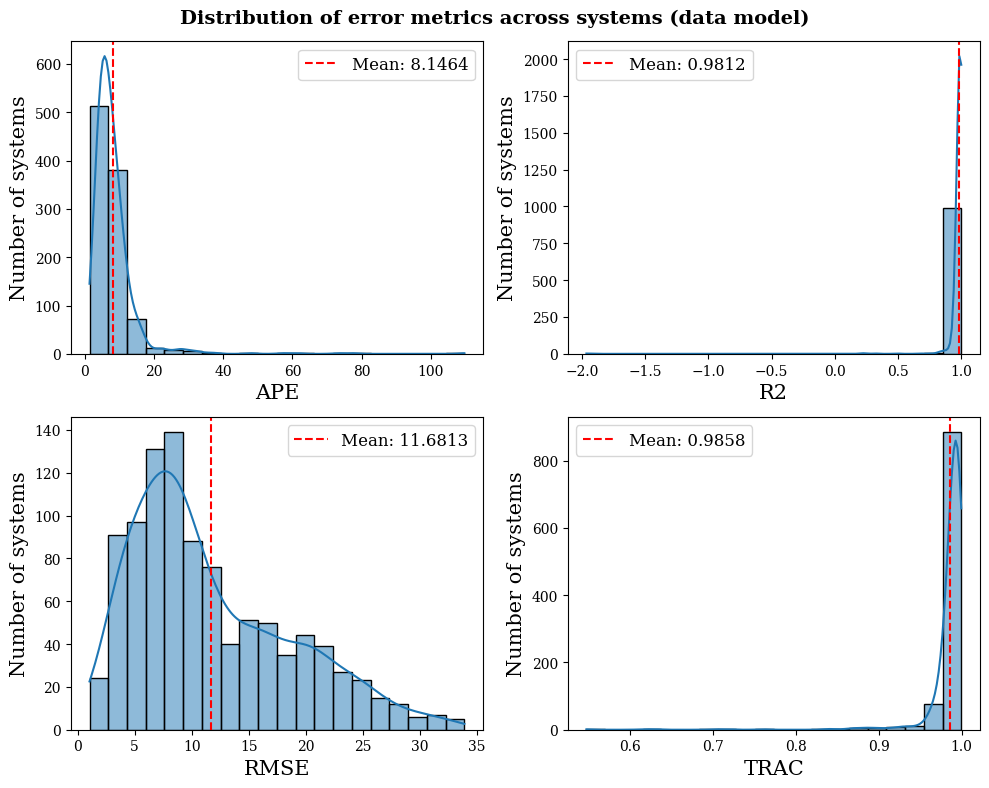

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, col in zip(axes, metric_cols):
    sns.histplot(df_graph, x=col, bins=20, ax=ax, color=COLOR_DATA, kde=True)
    ax.axvline(df_graph[col].mean(), color="red", linestyle="--", linewidth=1.5,
               label=f"Mean: {df_graph[col].mean():.4f}")
    ax.set_xlabel(col.upper(), fontsize=label_font)
    ax.set_ylabel("Number of systems", fontsize=label_font)
    ax.legend(fontsize=legend_font)

fig.suptitle("Distribution of error metrics across systems (data model)", fontsize=title_font, weight="bold")
plt.tight_layout()
plt.show()